# EDA y Modelo Baseline (Sprint 1)

Análisis exploratorio, validación de hipótesis de negocio y entrenamiento de regresión logística baseline sin fuga de datos.

## 1. Importación de Librerías

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="muted")

## 2. Carga de Master Table

In [2]:
PROJECT_ROOT = Path("../..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_table_path = PROCESSED_DIR / "master_table.parquet"

df = pd.read_parquet(master_table_path)
print(f"Master Table cargada con éxito. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Master Table cargada con éxito. Filas: 96096, Columnas: 28


,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_orders,total_items,total_products,avg_review_score,total_reviews,first_purchase,last_purchase,avg_delivery_days,avg_estimated_delivery_days,delivered_orders,canceled_orders,late_deliveries,payment_methods_count,main_payment_type,total_spent,avg_ticket,avg_order_price,avg_freight_value,avg_freight_ratio,recency_days,customer_lifetime_days,cancellation_rate,late_delivery_rate,is_premium
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,1,1.0,1.0,4.0,1.0,2017-05-16 15:05:35,2017-05-16 15:05:35,8.0,19.0,1,0,0,1.0,credit_card,146.87,146.87,124.99,21.88,0.148975,519,0,0.0,0.0,0
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,1,1.0,1.0,5.0,1.0,2018-01-12 20:48:24,2018-01-12 20:48:24,16.0,24.0,1,0,0,1.0,credit_card,335.48,335.48,289.00,46.48,0.138548,277,0,0.0,0.0,1
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1,1.0,1.0,5.0,1.0,2018-05-19 16:07:45,2018-05-19 16:07:45,26.0,24.0,1,0,1,1.0,credit_card,157.73,157.73,139.94,17.79,0.112788,151,0,0.0,1.0,0
3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,1,1.0,1.0,5.0,1.0,2018-03-13 16:06:38,2018-03-13 16:06:38,14.0,27.0,1,0,0,1.0,credit_card,173.30,173.30,149.94,23.36,0.134795,218,0,0.0,0.0,0
4,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,1,1.0,1.0,5.0,1.0,2018-07-29 09:51:30,2018-07-29 09:51:30,11.0,16.0,1,0,0,1.0,credit_card,252.25,252.25,230.00,22.25,0.088206,80,0,0.0,0.0,1


## 3. Estructura y Valores Nulos

In [3]:
print("===== Tipos de datos e Información general =====")
df.info()

print("\n===== Valores Nulos por Columna =====")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
if len(nulls) > 0:
    display(pd.DataFrame({"Nulls Count": nulls, "Proportion": nulls / len(df)}))
else:
    print("No hay valores nulos en el dataset.")

===== Tipos de datos e Información general =====
<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   customer_unique_id           96096 non-null  str           
 1   customer_zip_code_prefix     96096 non-null  int64         
 2   customer_city                96096 non-null  str           
 3   customer_state               96096 non-null  str           
 4   total_orders                 96096 non-null  int64         
 5   total_items                  96096 non-null  float64       
 6   total_products               96096 non-null  float64       
 7   avg_review_score             95380 non-null  float64       
 8   total_reviews                96096 non-null  float64       
 9   first_purchase               96096 non-null  datetime64[us]
 10  last_purchase                96096 non-null  datetime64[us]
 11  avg

,Nulls Count,Proportion
avg_delivery_days,2740,0.028513
avg_ticket,2739,0.028503
avg_order_price,2738,0.028492
avg_freight_value,2738,0.028492
avg_freight_ratio,2738,0.028492
avg_review_score,716,0.007451
main_payment_type,1,0.000010
payment_methods_count,1,0.000010


## 4. Análisis Univariado del Target

In [4]:
print("===== Distribución de la variable Target (is_premium) =====")
target_counts = df["is_premium"].value_counts()
target_props = df["is_premium"].value_counts(normalize=True)
display(pd.DataFrame({"Clientes": target_counts, "Proporción": target_props}))

# Graficar distribución y justificar el target monetario con el P80
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x="is_premium", hue="is_premium", ax=axes[0], palette=["#90caf9", "#1565c0"], legend=False)
axes[0].set_title("Distribución del Target (is_premium)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Es Premium (0 = Regular, 1 = Premium)")
axes[0].set_ylabel("Número de Clientes")
axes[0].set_xticklabels(["Regular (80%)", "Premium (20%)"])

# Histograma de distribución real de gasto acumulado con línea P80
spent_cap = df["total_spent"].quantile(0.99)
filtered_spent = df[df["total_spent"] <= spent_cap]["total_spent"]
sns.histplot(filtered_spent, bins=50, kde=True, color="#1565c0", alpha=0.7, ax=axes[1])
axes[1].axvline(x=205.18, color="#d32f2f", linestyle="--", linewidth=2.5, 
                label="P80 (Umbral Premium) = USD 205.18")
axes[1].set_title("La Distribución Real del Dinero: Justificación del Target", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Gasto Acumulado por Cliente (USD)")
axes[1].set_ylabel("Número de Clientes")
axes[1].set_xlim(0, spent_cap)
axes[1].legend(fontsize=10, loc="upper right")
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Análisis del Target Premium y Distribución Monetaria", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Distribución RFM (Recency, Frequency, Monetary)

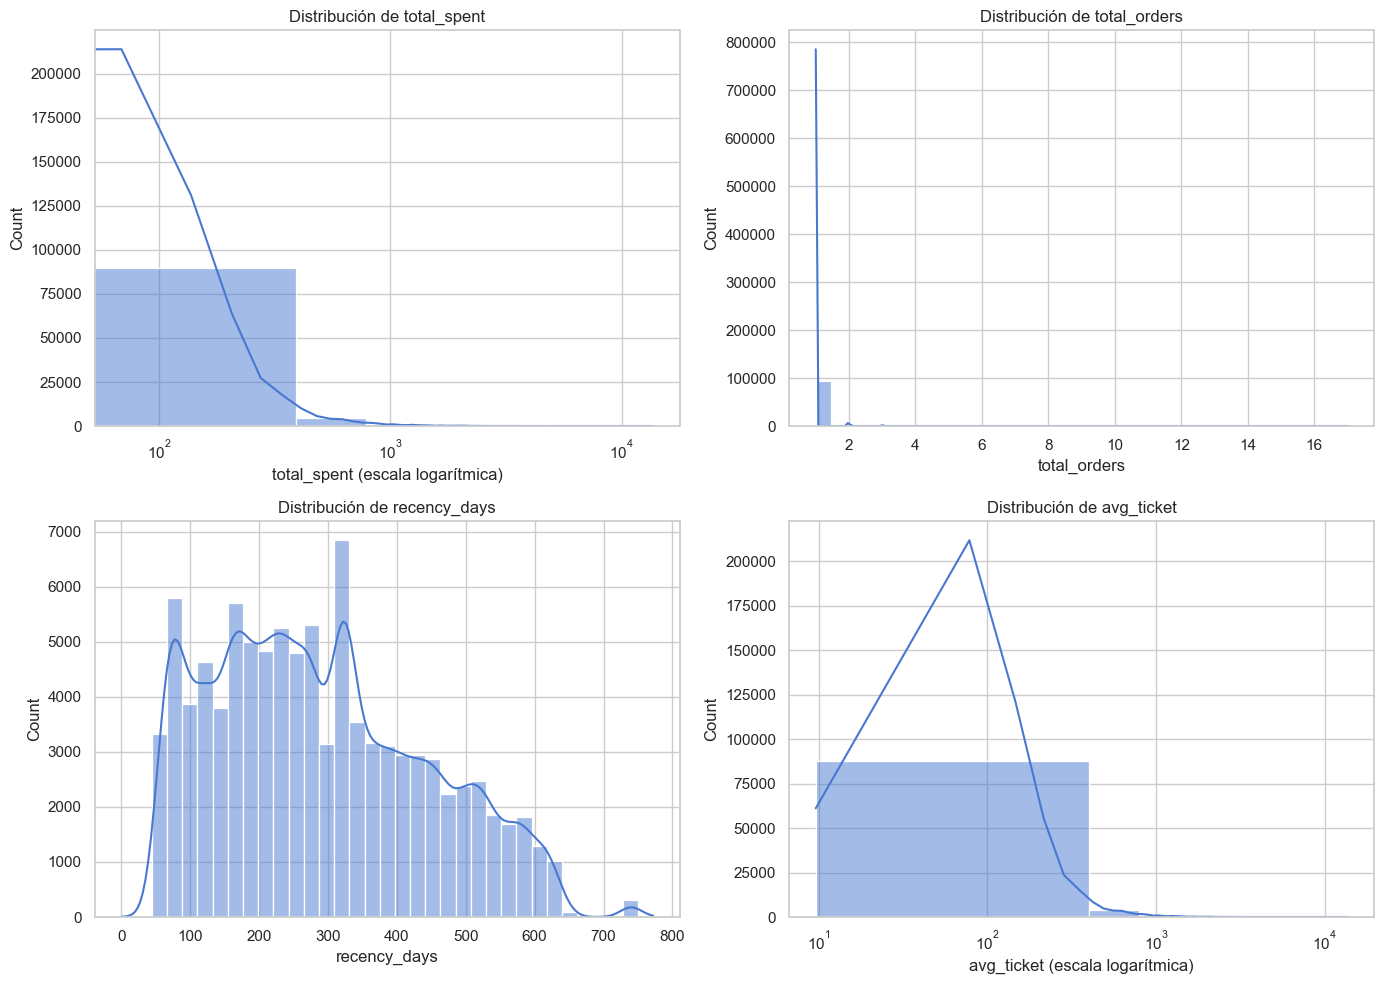

In [5]:
rfm_cols = ["total_spent", "total_orders", "recency_days", "avg_ticket"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(rfm_cols):
    # Evitar log(0)
    data_to_plot = df[col]
    if col in ["total_spent", "avg_ticket"]:
        data_to_plot = data_to_plot[data_to_plot > 0]
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=35)
    axes[i].set_title(f"Distribución de {col}")
    if col in ["total_spent", "avg_ticket"]:
        axes[i].set_xscale("log")
        axes[i].set_xlabel(f"{col} (escala logarítmica)")
plt.tight_layout()
plt.show()

## 5. Análisis Bivariado (Regular vs Premium)

In [6]:
# 1. Gasto Acumulado por segmento (que define si es premium)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_premium", y="total_spent", hue="is_premium", palette=["#90caf9", "#1565c0"], showfliers=False, legend=False)
plt.yscale("log")
plt.title("Diferencia Monetaria: Gasto Total Acumulado por Segmento", fontsize=13, fontweight='bold')
plt.xlabel("Segmento")
plt.ylabel("Gasto Total Acumulado (USD, escala logarítmica)")
plt.xticks([0, 1], ["Regular", "Premium"])
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Comparación de Frecuencia, Recencia y Calificaciones (El Cliente Premium No Es Quien Creíamos)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
palette = ["#90caf9", "#1565c0"]

# Frecuencia
sns.boxplot(data=df, x="is_premium", y="total_orders", ax=axes[0], hue="is_premium", palette=palette, showfliers=False, legend=False)
axes[0].set_title("Frecuencia (Órdenes Totales)", fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1], ["Regular", "Premium"])
axes[0].set_xlabel("")
axes[0].set_ylabel("Cantidad de Órdenes")
axes[0].grid(axis='y', alpha=0.3)

# Recencia
sns.boxplot(data=df, x="is_premium", y="recency_days", ax=axes[1], hue="is_premium", palette=palette, showfliers=False, legend=False)
axes[1].set_title("Recencia (Días desde última compra)", fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1], ["Regular", "Premium"])
axes[1].set_xlabel("")
axes[1].set_ylabel("Días")
axes[1].grid(axis='y', alpha=0.3)

# Satisfacción (Review Score)
sns.boxplot(data=df, x="is_premium", y="avg_review_score", ax=axes[2], hue="is_premium", palette=palette, showfliers=False, legend=False)
axes[2].set_title("Satisfacción (Review Score)", fontsize=12, fontweight='bold')
axes[2].set_xticks([0, 1], ["Regular", "Premium"])
axes[2].set_xlabel("")
axes[2].set_ylabel("Puntaje promedio")
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle("El Cliente Premium No Es Quien Creíamos: Comportamiento no monetario casi idéntico", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Distribución Geográfica del Segmento Premium

/tmp/ipykernel_128797/2653902474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")


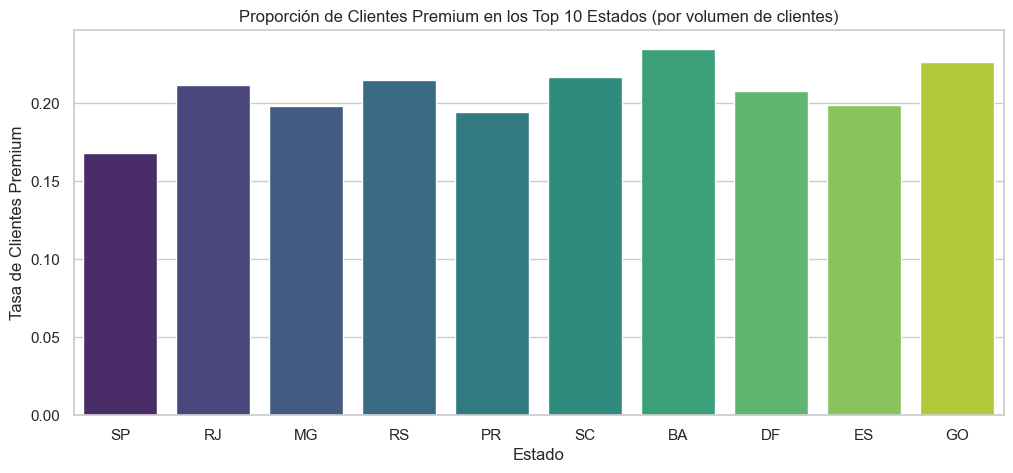

,customer_state,clientes,premium,proporcion_premium
25,SP,40292,6776,0.168172
18,RJ,12383,2621,0.211661
10,MG,11253,2232,0.198347
22,RS,5275,1135,0.215166
17,PR,4878,949,0.194547
23,SC,3532,766,0.216874
4,BA,3276,770,0.235043
6,DF,2073,431,0.207911
7,ES,1964,391,0.199084
8,GO,1950,442,0.226667


In [7]:
state_summary = df.groupby("customer_state").agg(
    clientes=("customer_unique_id", "count"),
    premium=("is_premium", "sum"),
    proporcion_premium=("is_premium", "mean")
).reset_index()

state_summary = state_summary.sort_values(by="clientes", ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=state_summary, x="customer_state", y="proporcion_premium", palette="viridis")
plt.title("Proporción de Clientes Premium en los Top 10 Estados (por volumen de clientes)")
plt.xlabel("Estado")
plt.ylabel("Tasa de Clientes Premium")
plt.show()

display(state_summary)

## 7. Matriz de Correlación

===== Correlación de Pearson con is_premium =====
is_premium                     1.000000
total_spent                    0.611573
avg_ticket                     0.593267
avg_order_price                0.580356
avg_freight_value              0.393834
total_items                    0.236248
total_products                 0.192890
delivered_orders               0.169287
total_orders                   0.147179
total_reviews                  0.125135
avg_estimated_delivery_days    0.108290
customer_lifetime_days         0.103388
avg_delivery_days              0.073041
customer_zip_code_prefix       0.060665
late_deliveries                0.026645
late_delivery_rate             0.017865
payment_methods_count          0.000474
recency_days                  -0.008337
avg_review_score              -0.015194
canceled_orders               -0.029630
cancellation_rate             -0.034565
avg_freight_ratio             -0.382435
Name: is_premium, dtype: float64


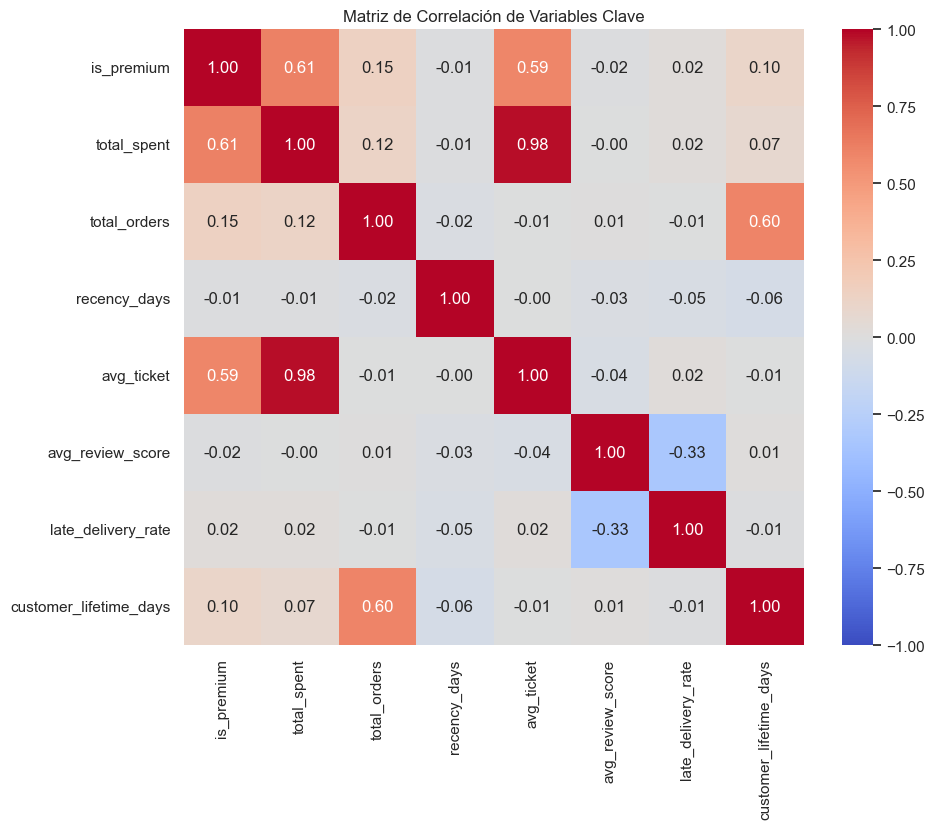

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["is_premium"].sort_values(ascending=False)
print("===== Correlación de Pearson con is_premium =====")
print(correlations)

key_vars = [
    "is_premium", "total_spent", "total_orders", "recency_days", 
    "avg_ticket", "avg_review_score", "late_delivery_rate", "customer_lifetime_days"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[key_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de Variables Clave")
plt.show()

## 8. Validación de Hipótesis de Negocio

In [9]:
print("===== Validación Hipótesis 1 (Frecuencia de compra) =====")
display(df.groupby("is_premium")["total_orders"].agg(["mean", "median", "max", "count"]))

print("\n===== Validación Hipótesis 2 (Calificaciones) =====")
display(df.groupby("is_premium")["avg_review_score"].agg(["mean", "median", "std"]))

print("\n===== Validación Hipótesis 3 (Logística y Retrasos) =====")
display(df.groupby("is_premium")["late_delivery_rate"].agg(["mean", "max"]))

print("\n===== Otras comparativas de negocio clave =====")
display(df.groupby("is_premium").agg(
    ticket_medio=("avg_ticket", "mean"),
    dias_lifetime_medio=("customer_lifetime_days", "mean")
))

===== Validación Hipótesis 1 (Frecuencia de compra) =====


,mean,median,max,count
is_premium,,,,
0,1.019031,1.0,6,76874
1,1.097909,1.0,17,19222



===== Validación Hipótesis 2 (Calificaciones) =====


,mean,median,std
is_premium,,,
0,4.095153,5.0,1.333550
1,4.044182,5.0,1.372925



===== Validación Hipótesis 3 (Logística y Retrasos) =====


,mean,max
is_premium,,
0,0.076710,1.0
1,0.088695,1.0



===== Otras comparativas de negocio clave =====


,ticket_medio,dias_lifetime_medio
is_premium,,
0,93.986304,1.398717
1,416.138103,7.961711


### Análisis Operacional:

* **Frecuencia (H1):** La frecuencia promedio es similar (~1.0 vs ~1.1). La diferenciación es monetaria.
* **Satisfacción (H2):** Clientes premium puntúan ligeramente menos (4.04 vs 4.09), indicando mayor nivel de exigencia.
* **Retrasos (H3):** Los clientes premium sufren más demoras (8.87% vs 7.67%), posiblemente debido a la complejidad de envío de artículos caros o voluminosos.

## 9. Modelo Baseline

Entrenamiento de una Regresión Logística simple con split train/test inicial e imputación neutral basada únicamente en entrenamiento.

===== REPORTE DE CLASIFICACIÓN (Baseline Logístico) =====
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     23062
           1       0.30      0.16      0.21      5767

    accuracy                           0.76     28829
   macro avg       0.56      0.53      0.53     28829
weighted avg       0.71      0.76      0.73     28829

ROC-AUC Score: 0.5355


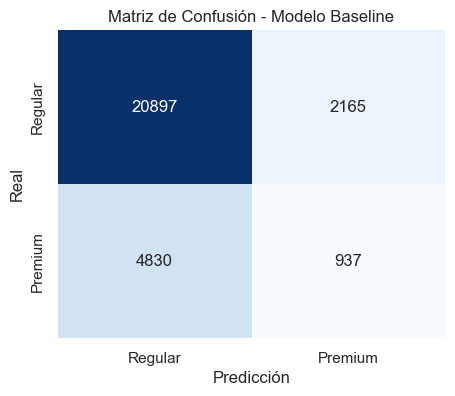

In [10]:
# 1. Crear variable indicadora de reseña ausente
df["review_is_missing"] = df["avg_review_score"].isna().astype(int)

features = [
    "total_orders", "recency_days", "customer_lifetime_days", 
    "avg_review_score", "review_is_missing", "late_delivery_rate", "payment_methods_count"
]
X = df[features].copy()
y = df["is_premium"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

train_mean_review = X_train["avg_review_score"].mean()

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

X_train_imputed["avg_review_score"] = X_train_imputed["avg_review_score"].fillna(train_mean_review)
X_test_imputed["avg_review_score"] = X_test_imputed["avg_review_score"].fillna(train_mean_review)

# Imputación de posibles nulos en otras columnas usando mediana de train
for col in features:
    if col != "avg_review_score":
        train_median = X_train[col].median()
        X_train_imputed[col] = X_train_imputed[col].fillna(train_median)
        X_test_imputed[col] = X_test_imputed[col].fillna(train_median)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

baseline_model = LogisticRegression(class_weight="balanced", random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# 6. Predicciones
y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

# 7. Evaluación de Métricas Técnicas
print("===== REPORTE DE CLASIFICACIÓN (Baseline Logístico) =====")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Regular", "Premium"], yticklabels=["Regular", "Premium"])
plt.title("Matriz de Confusión - Modelo Baseline")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 10. Comparacion de Modelos

Se compara el baseline logistico contra modelos no lineales con la misma separacion train/test y evitando fuga de datos.
Criterio principal de seleccion: **ROC-AUC** en test.

In [ ]:
# Comparacion de modelos
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", random_state=42, max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

if XGBClassifier is not None:
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
    )
else:
    print("XGBoost no disponible en el entorno. Se omite del benchmark.")

results = []

for name, model in models.items():
    # Modelos lineales usan features escalados
    if name == "LogisticRegression":
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train_imputed, X_test_imputed

    model.fit(Xtr, y_train)
    yhat = model.predict(Xte)

    if hasattr(model, "predict_proba"):
        yscore = model.predict_proba(Xte)[:, 1]
    else:
        yscore = yhat

    auc = roc_auc_score(y_test, yscore)

    results.append(
        {
            "model": name,
            "roc_auc": auc,
            "gini": 2 * auc - 1,
            "precision_premium": precision_score(y_test, yhat, zero_division=0),
            "recall_premium": recall_score(y_test, yhat, zero_division=0),
            "f1_premium": f1_score(y_test, yhat, zero_division=0),
        }
    )

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, "model"]
best_model_auc = results_df.loc[0, "roc_auc"]
print(f"Mejor modelo por ROC-AUC: {best_model_name} ({best_model_auc:.4f})")

## 11. Conclusiones

* El baseline logistico libre de data leakage marca un piso tecnico para el Sprint 1.
* El benchmark multmodelo permite seleccionar el mejor enfoque actual por ROC-AUC de forma reproducible.
* Si el mejor modelo sigue siendo modesto, se confirma la necesidad de enriquecer variables (categoria de producto, cuotas, geografia) y probar ajustes de hiperparametros en Sprint 2.